In [295]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [296]:
df = pd.read_csv('data_w_genres.csv', delimiter=',')
df.head()

,genres,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
0,['show tunes'],"""Cats"" 1981 Original London Cast",0.590111,0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5,1,9
1,[],"""Cats"" 1983 Broadway Cast",0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5,1,26
2,[],"""Fiddler On The Roof” Motion Picture Chorus",0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0,1,7
3,[],"""Fiddler On The Roof” Motion Picture Orchestra",0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0,1,27
4,[],"""Joseph And The Amazing Technicolor Dreamcoat""...",0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5,1,7


    Data Analysis

In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28680 entries, 0 to 28679
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genres            28680 non-null  object 
 1   artists           28680 non-null  object 
 2   acousticness      28680 non-null  float64
 3   danceability      28680 non-null  float64
 4   duration_ms       28680 non-null  float64
 5   energy            28680 non-null  float64
 6   instrumentalness  28680 non-null  float64
 7   liveness          28680 non-null  float64
 8   loudness          28680 non-null  float64
 9   speechiness       28680 non-null  float64
 10  tempo             28680 non-null  float64
 11  valence           28680 non-null  float64
 12  popularity        28680 non-null  float64
 13  key               28680 non-null  int64  
 14  mode              28680 non-null  int64  
 15  count             28680 non-null  int64  
dtypes: float64(11), int64(3), object(2)
memo

In [298]:
df.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
count,28680.000000,28680.000000,2.868000e+04,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000
mean,0.498373,0.546490,2.388780e+05,0.497488,0.174756,0.202441,-11.140498,0.094014,115.844830,0.512723,34.060945,5.412901,0.759170,13.847211
std,0.370614,0.176474,1.211318e+05,0.254885,0.298406,0.140884,5.771749,0.111986,25.003834,0.244421,22.376438,3.480552,0.427595,53.372544
min,0.000000,0.000000,1.879550e+04,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.122296,0.431000,1.823304e+05,0.283568,0.000004,0.110362,-13.972292,0.039200,99.366500,0.329000,12.000000,2.000000,1.000000,2.000000
50%,0.478458,0.557000,2.186400e+05,0.504000,0.001880,0.161000,-10.088938,0.052200,115.357400,0.523243,39.000000,6.000000,1.000000,3.000000
75%,0.896000,0.675000,2.684670e+05,0.702783,0.215291,0.247000,-6.889000,0.095300,129.848750,0.703000,51.000000,8.000000,1.000000,8.000000
max,0.996000,0.986000,5.403500e+06,1.000000,1.000000,0.991000,1.342000,0.964000,217.743000,0.991000,93.000000,11.000000,1.000000,3169.000000


data cleaning 

In [299]:

def clean_genres(genre_str):
    if genre_str == "[]" or pd.isna(genre_str):  
        return None 
    
    genre_str = genre_str.strip("[]") 
    genre_str = genre_str.replace("'", "")  
    genre_str = genre_str.replace('"', '') 
    
    return genre_str if genre_str else None 

df['genres'] = df['genres'].apply(clean_genres) 
df.head(10)

,genres,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
0,show tunes,"""Cats"" 1981 Original London Cast",0.590111,0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5,1,9
1,None,"""Cats"" 1983 Broadway Cast",0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5,1,26
2,None,"""Fiddler On The Roof” Motion Picture Chorus",0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0,1,7
3,None,"""Fiddler On The Roof” Motion Picture Orchestra",0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0,1,27
4,None,"""Joseph And The Amazing Technicolor Dreamcoat""...",0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5,1,7
5,None,"""Joseph And The Amazing Technicolor Dreamcoat""...",0.609556,0.487278,205091.944444,0.309906,0.004696,0.274767,-18.266389,0.098022,118.648944,0.441556,32.777778,5,1,36
6,None,"""Mama"" Helen Teagarden",0.725000,0.637000,135533.000000,0.512000,0.186000,0.426000,-20.615000,0.210000,134.819000,0.885000,0.000000,8,1,2
7,None,"""Test for Victor Young""",0.927000,0.734000,175693.000000,0.474000,0.076200,0.737000,-10.544000,0.256000,132.788000,0.902000,3.000000,10,1,2
8,"comedy rock, comic, parody","""Weird Al"" Yankovic",0.173145,0.662787,218948.196721,0.695393,0.000050,0.161102,-9.768705,0.084536,133.031180,0.751344,34.229508,9,1,122
9,"emo rap, florida rap, sad rap, underground hip...",$NOT,0.544467,0.789800,137910.466667,0.532933,0.023063,0.180300,-9.149267,0.293687,112.344800,0.480700,67.533333,1,1,15


In [300]:
df.drop('artists', axis=1, inplace=True)
df

,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
0,show tunes,0.590111,0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5,1,9
1,None,0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5,1,26
2,None,0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0,1,7
3,None,0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0,1,27
4,None,0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28675,None,0.512000,0.356000,198773.000000,0.306000,0.008970,0.108000,-10.119000,0.027700,150.049000,0.328000,35.000000,10,1,2
28676,"c-pop, classic cantopop, classic mandopop, man...",0.541000,0.578000,293840.000000,0.334000,0.000006,0.067500,-11.974000,0.026700,135.934000,0.243000,48.000000,9,0,2
28677,None,0.785455,0.570818,174582.727273,0.148400,0.000083,0.142191,-21.610091,0.054355,119.586273,0.741273,23.000000,5,1,11
28678,"chinese indie, chinese indie rock",0.381000,0.353000,316160.000000,0.686000,0.000000,0.056800,-9.103000,0.039500,200.341000,0.352000,35.000000,11,1,2


In [301]:

# Complete genre mapping dictionary
genre_mapping = {
    "Soundtrack/Musical": ["movie tunes", "show tunes", "hollywood", "broadway"],
    "Classical": ["orchestra", "classical", "symphony"],
    "Hip Hop": ["hip hop", "rap", "trap"],
    "Reggae": ["reggae", "dancehall", "lovers rock"],
    "Children's Music": ["children", "enfants"],
    "Indie": ["indie"],
    "Pop": ["pop"],
    "Rock": ["rock"],
    "Electronic/Dance": ["electronic", "edm", "house", "techno", "dance"],
    "World/Traditional": ["latin", "folk", "african", "asian", "world", "traditional"]
}

def map_genre(music_genres, song_name):
    if song_name != None:
        song_name = song_name.lower()  
    
        # Check for prefix matches first
        for genre, prefixes in music_genres.items():
            for prefix in prefixes:
                if song_name.startswith(prefix.lower()):
                    return genre
        
        # Check for substring matches
        for genre in music_genres.keys():
            if genre.lower() in song_name:
                return genre
    else:
        pass

# Apply the function with lambda to pass both arguments
df["genre"] = df["genres"].apply(lambda song: map_genre(genre_mapping, song))

df


,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count,genre
0,show tunes,0.590111,0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5,1,9,Soundtrack/Musical
1,None,0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5,1,26,None
2,None,0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0,1,7,None
3,None,0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0,1,27,None
4,None,0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5,1,7,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28675,None,0.512000,0.356000,198773.000000,0.306000,0.008970,0.108000,-10.119000,0.027700,150.049000,0.328000,35.000000,10,1,2,None
28676,"c-pop, classic cantopop, classic mandopop, man...",0.541000,0.578000,293840.000000,0.334000,0.000006,0.067500,-11.974000,0.026700,135.934000,0.243000,48.000000,9,0,2,Pop
28677,None,0.785455,0.570818,174582.727273,0.148400,0.000083,0.142191,-21.610091,0.054355,119.586273,0.741273,23.000000,5,1,11,None
28678,"chinese indie, chinese indie rock",0.381000,0.353000,316160.000000,0.686000,0.000000,0.056800,-9.103000,0.039500,200.341000,0.352000,35.000000,11,1,2,Indie


In [302]:
df.drop('genres', axis=1, inplace=True)

In [303]:
features = [
    "genre","danceability", "energy", "valence",
    "acousticness", "instrumentalness",
    "liveness", "loudness", "speechiness", "tempo"
]
df=df[features]

In [304]:
#drop rows with missing genre
df.dropna(subset=['genre'], inplace=True)
df

C:\Users\steph\AppData\Local\Temp\ipykernel_81240\2228077392.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['genre'], inplace=True)


,genre,danceability,energy,valence,acousticness,instrumentalness,liveness,loudness,speechiness,tempo
0,Soundtrack/Musical,0.467222,0.394003,0.389500,0.590111,0.011400,0.290833,-14.448000,0.210389,117.518111
8,Rock,0.662787,0.695393,0.751344,0.173145,0.000050,0.161102,-9.768705,0.084536,133.031180
9,Hip Hop,0.789800,0.532933,0.480700,0.544467,0.023063,0.180300,-9.149267,0.293687,112.344800
12,World/Traditional,0.854000,0.683000,0.625500,0.148100,0.000002,0.188500,-6.997000,0.221000,100.724500
13,Hip Hop,0.749344,0.635552,0.287286,0.141485,0.045675,0.202253,-6.631304,0.156108,115.022024
...,...,...,...,...,...,...,...,...,...,...
28667,Pop,0.550000,0.375000,0.405000,0.562000,0.000004,0.244000,-12.277000,0.033200,75.703000
28673,Pop,0.358000,0.208000,0.278000,0.884000,0.000002,0.150000,-9.524000,0.033900,131.261000
28676,Pop,0.578000,0.334000,0.243000,0.541000,0.000006,0.067500,-11.974000,0.026700,135.934000
28678,Indie,0.353000,0.686000,0.352000,0.381000,0.000000,0.056800,-9.103000,0.039500,200.341000


In [305]:
df = df.dropna()
df = df.drop_duplicates()

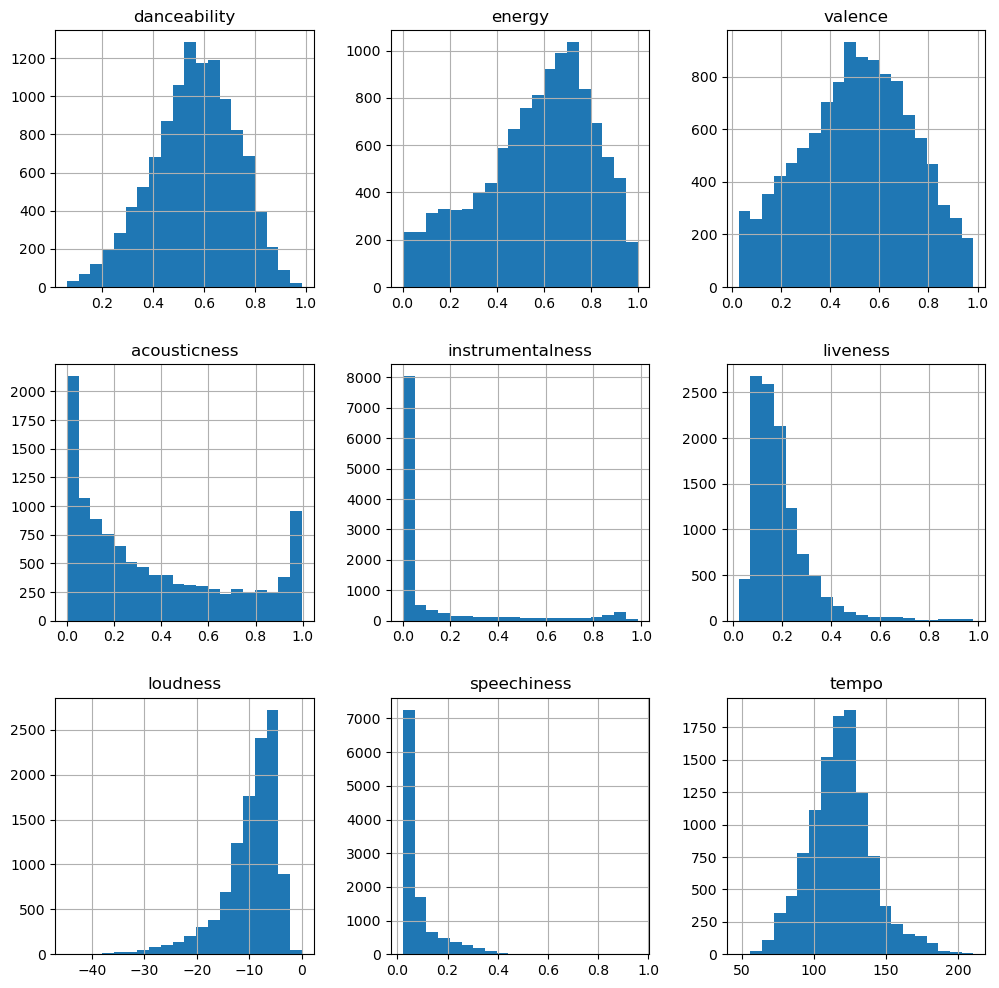

In [306]:
df.hist(bins=20,figsize=(12,12))
plt.show()

<Axes: >

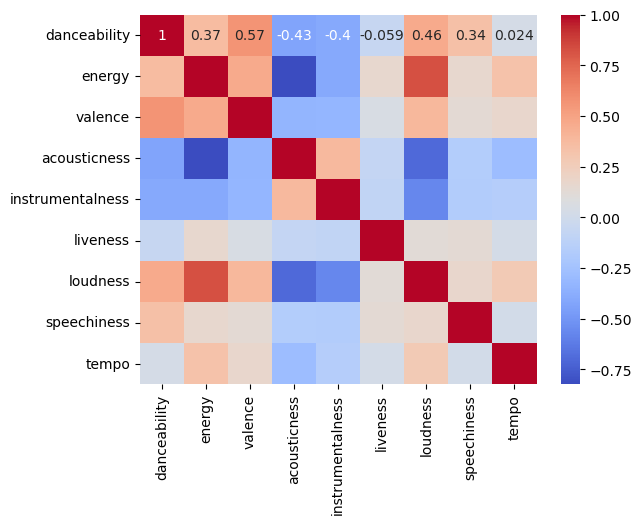

In [307]:
df_feature=[
    "danceability", "energy", "valence",
    "acousticness", "instrumentalness",
    "liveness", "loudness", "speechiness", "tempo"
]
numerical=df[df_feature]
sns.heatmap(numerical.corr(), annot=True, cmap="coolwarm")

<Axes: ylabel='genre'>

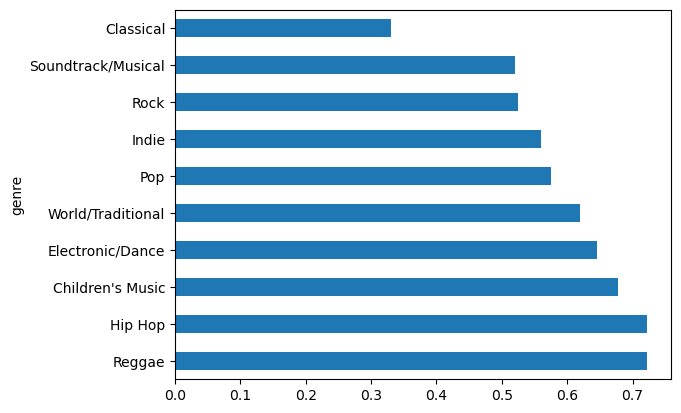

In [308]:
genre_dance = df.groupby("genre")["danceability"].mean().sort_values(ascending=False)
genre_energy = df.groupby("genre")["energy"].mean().sort_values(ascending=False)
genre_dance.plot(kind="barh")

    Data Preprocessing 

In [309]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(numerical)

    PCA

In [310]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit_transform(X)

array([[ 0.93009183,  0.76178569,  1.58348976, ...,  0.33947874,
         0.35991425,  0.07016546],
       [-1.32457378,  0.07016823, -0.58845983, ...,  0.08919354,
         0.46078192,  0.15314586],
       [-0.67741998,  2.28744521,  0.75883351, ..., -0.18528507,
        -0.47247405,  0.27783305],
       ...,
       [ 1.10498766, -0.45276568, -1.08524631, ..., -0.86690241,
        -0.02717798,  0.02290956],
       [-0.27399958, -2.98850157, -1.13665787, ...,  0.14627518,
        -0.08956996,  0.35546709],
       [ 2.66062543,  0.82952646, -0.65874249, ...,  0.00405932,
         0.66706412, -0.04775096]])

In [311]:
pca.n_components_

9

In [312]:
eig = pd.DataFrame(
    {
        "Dimension" : ["Dim" + str(x+1) for x in range(9)],
        "Explained Variance" : pca.explained_variance_,
        "% explained variance" : np.round(pca.explained_variance_ratio_*100),
        "% cumulative expl. variance" : np.round(np.cumsum(pca.explained_variance_ratio_)*100)
    }
)
eig

,Dimension,Explained Variance,% explained variance,% cumulative expl. variance
0,Dim1,3.729747,41.0,41.0
1,Dim2,1.207028,13.0,55.0
2,Dim3,1.072248,12.0,67.0
3,Dim4,0.823111,9.0,76.0
4,Dim5,0.758923,8.0,84.0
5,Dim6,0.692258,8.0,92.0
6,Dim7,0.362469,4.0,96.0
7,Dim8,0.264557,3.0,99.0
8,Dim9,0.090470,1.0,100.0


In [313]:
n_cps = 5
pca = PCA(n_components=n_cps)

X = pd.DataFrame(
    data=pca.fit_transform(X),
    columns=['PCA1','PCA2','PCA3','PCA4','PCA5']
)

X.head()

,PCA1,PCA2,PCA3,PCA4,PCA5
0,0.930092,0.761786,1.583490,0.890935,-0.134908
1,-1.324574,0.070168,-0.588460,0.271786,0.682706
2,-0.677420,2.287445,0.758834,1.367430,-0.677837
3,-1.794454,2.010505,0.303038,0.205337,-0.624368
4,-0.964641,0.554847,0.431535,0.275013,-1.225229


    Culstering

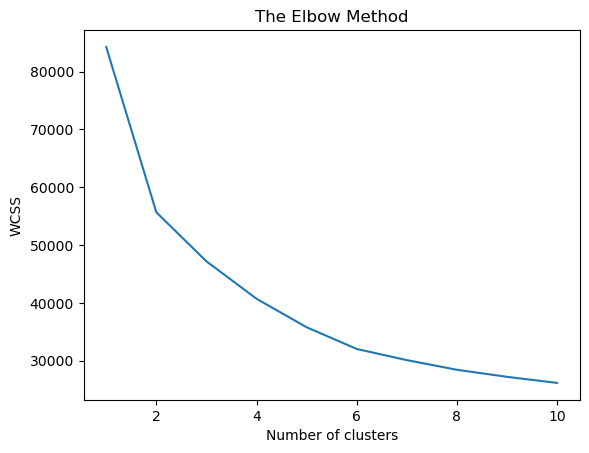

In [314]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++',n_init=10 ,random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
range_clusters = range(2, 8)  # Try between 2 and 7 clusters
silhouette_scores = []

for n_clusters in range_clusters:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting the silhouette scores
plt.plot(range_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Score Method")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 6, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
y_kmeans = np.array(kmeans.labels_ )
df['kmeans_clusters'] = y_kmeans

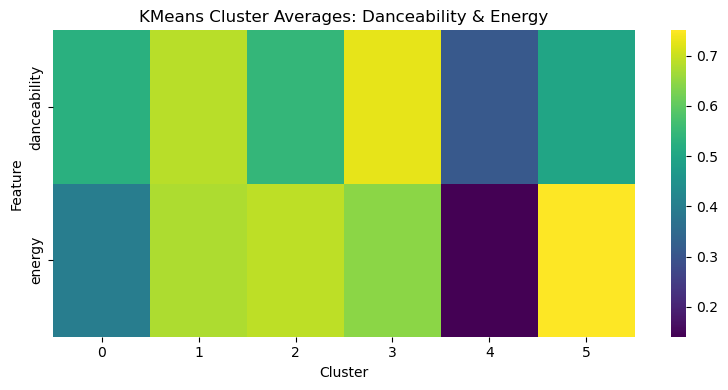

In [ ]:
cluster_summary = df.groupby('kmeans_clusters')[['danceability', 'energy']].mean().T

plt.figure(figsize=(8, 4))
sns.heatmap(cluster_summary, cmap='viridis', fmt=".2f")
plt.title('KMeans Cluster Averages: Danceability & Energy')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This heatmap visualizes the average danceability and energy values for each cluster produced by the KMeans.

Cluster 3 has the highest danceability and energy, matching Electronic/Dance, Pop, or high-tempo Hip Hop tracks.

Cluster 4 is the least energetic and least danceable, strongly pointing to Classical or Children’s Music.

Cluster 5 shows high energy but only medium danceability, which aligns with genres like Rock or more intense Electronic.

Cluster 1 is another strong candidate for Pop, Dance, or mainstream Hip Hop.

Cluster 2 might be attributed to Regga but also to Pop and Hip Hop.

Cluster 0 likely includes more niche, mellow genres like Indie, World, or Soundtrack music.

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=8)
labels = dbscan.fit_predict(X)
df['dbscan_clusters'] = labels

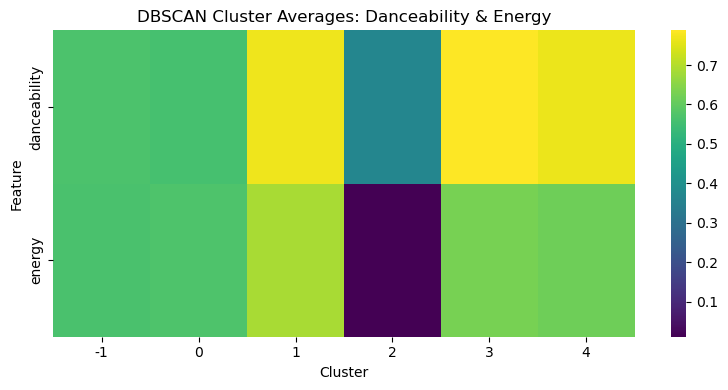

In [ ]:
cluster_summary = df.groupby('dbscan_clusters')[['danceability', 'energy']].mean().T

plt.figure(figsize=(8, 4))
sns.heatmap(cluster_summary, cmap='viridis', fmt=".2f")
plt.title('DBSCAN Cluster Averages: Danceability & Energy')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This heatmap shows the average values of danceability and energy for each cluster found by the DBSCAN algorithm. DBSCAN also includes a cluster labeled -1, which represents outliers (i.e., noise points not assigned to any main cluster).

Cluster 2 is clearly Classical or very low-energy Children’s Music.

Cluster 3 and 4 are both high in energy and danceability, pointing to Electronic/Dance, Reggae, or Hip Hop.

Cluster -1 (outliers) includes tracks that don't fit typical clusters—could be World, Soundtrack, or Indie.

Cluster 0 is more moderate and may include Indie, World, or Children’s genres.